# 01 — Data Understanding & Structuring

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

---

Inspects the raw workbook (`ifoCAST_DATA.xlsx`) before any modelling step.  
**Data files** go to `data/` (panel, metadata, QA); figures use the configured output directory.

**Contents:**

| Step | Task |
|------|------|
| 0 | Setup — paths, imports, output directories |
| 1 | Sheet overview — structure and content of all four sheets |
| 2 | Parse `Raw_Data` → predictor panel + metadata |
| 3 | Build data dictionary — variable catalogue for the thesis |
| 4 | Parse `GDP_realtime` → vintage matrix and first-release target |
| 5 | Data quality — coverage, missing values, stale series |
| 5b | Duplicate detection — exact and near-perfect value-based matches |
| 6 | Summary report |


---
## Step 0 — Setup

In [ ]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', font_scale=1.0)

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp

DATA_PATH = _tp.DATASET_XLSX
OUT_DIR = _tp.PROJECT_FILES
FIG_DIR = OUT_DIR / '01_data_understanding'
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH}'

print(f'Python  : {sys.version.split()[0]}')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'Dataset : {DATA_PATH.name}')
print('Setup OK')


---
## Step 1 — Sheet Overview

The Excel file contains four sheets.  Each sheet is loaded with `header=None` to preserve all rows exactly as stored.

| Sheet | Role |
|-------|------|
| `Macrobond Input` | Original Macrobond pull — source of `Raw_Data`; not used directly |
| `Raw_Data` | **Main predictor panel** — 653 monthly indicators, 1991-01 → 2026-04 |
| `Transformation` | Transformation codes (Trafo, Degree) per indicator — consistent with `Raw_Data` |
| `GDP_realtime` | **Target variable** — quarterly GDP index in 108 real-time vintages, 1991-Q1 → 2025-Q4 |

In [2]:
xl = pd.ExcelFile(DATA_PATH)
print('Sheets:', xl.sheet_names)

sheets_raw = {name: xl.parse(name, header=None) for name in xl.sheet_names}

print('\n--- Sheet dimensions ---')
for name, df in sheets_raw.items():
    print(f'  {name:<20s}: {df.shape[0]} rows × {df.shape[1]} cols')

Sheets: ['Macrobond Input', 'Raw_Data', 'Transformation', 'GDP_realtime']

--- Sheet dimensions ---
  Macrobond Input     : 433 rows × 654 cols
  Raw_Data            : 433 rows × 654 cols
  Transformation      : 7 rows × 654 cols
  GDP_realtime        : 151 rows × 109 cols


---
## Step 2 — Parse `Raw_Data`

We split the sheet into two objects:

- **`metadata_df`** (653 × 7): one row per indicator — ID, name, unit, category, trafo, degree, block, factor_data flag.
- **`data_df`** (424 × 653): the monthly predictor panel with a proper `DatetimeIndex`.

Note: `data_df` contains **predictors only**. German GDP is in `GDP_realtime` (the target variable) and is handled separately in Step 4.

In [3]:
def parse_raw_data(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parse the Raw_Data sheet (wide-transposed, header=None).

    Layout (header=None, shape 433×654):
        row 0        : Excel column-label row  (Index, 1, 2, ...)  — skipped
        rows 1-8     : per-indicator metadata  (Name, ID, Unit, Category,
                        Trafo, Degree, Block, Factor Data)
        rows 9-432   : monthly time series     (1991-01-01 → 2026-04-01)
        col 0        : row label;  cols 1+ : indicator values

    Returns
    -------
    metadata_df : DataFrame (N_indicators × 8), indexed by indicator ID
    data_df     : DataFrame (N_months × N_indicators), DatetimeIndex, columns = IDs
    """
    META_LABELS = ['name', 'id', 'unit', 'category', 'trafo', 'degree', 'block', 'factor_data']
    META_ROWS   = slice(1, 9)   # rows 1-8: metadata
    DATA_START  = 9             # row 9 onward: time series

    # --- metadata ---
    meta_vals   = df_raw.iloc[META_ROWS, 1:].values   # shape (8, N_indicators)
    metadata_df = pd.DataFrame(meta_vals.T, columns=META_LABELS)
    for col in ['trafo', 'degree', 'block', 'factor_data']:
        metadata_df[col] = pd.to_numeric(metadata_df[col], errors='coerce')
    metadata_df = metadata_df.set_index('id')
    metadata_df.index.name = 'id'

    # --- time-series panel ---
    data_block = df_raw.iloc[DATA_START:, :]
    dates      = pd.to_datetime(data_block.iloc[:, 0], errors='coerce')
    values     = data_block.iloc[:, 1:].copy()
    values.columns = metadata_df.index
    values.index   = dates
    values.index.name = 'date'
    values = values.apply(pd.to_numeric, errors='coerce')

    n_bad = values.index.isna().sum()
    if n_bad:
        print(f'WARNING: {n_bad} rows with unparseable dates dropped.')
        values = values.loc[values.index.notna()]

    return metadata_df, values


metadata_df, data_df = parse_raw_data(sheets_raw['Raw_Data'])

print(f'metadata_df : {metadata_df.shape[0]} indicators × {metadata_df.shape[1]} attributes')
print(f'data_df     : {data_df.shape[0]} months × {data_df.shape[1]} indicators')
print(f'Time range  : {data_df.index.min().strftime("%Y-%m")} → {data_df.index.max().strftime("%Y-%m")}')
print()
print('metadata_df — first 5 indicators:')
print(metadata_df.head())

metadata_df : 653 indicators × 7 attributes
data_df     : 424 months × 653 indicators
Time range  : 1991-01 → 2026-04

metadata_df — first 5 indicators:
                                                         name   unit    category  trafo  degree  block  factor_data
id                                                                                                                 
deprod1404  Germany, Industrial Production, Total, Calenda...  Index  Production      1       1      1            1
deprod1370  Germany, Industrial Production, Total, Excludi...  Index  Production      1       1      1            0
deprod1398  Germany, Industrial Production, Total, Excludi...  Index  Production      1       1      1            0
deprod1375  Germany, Industrial Production, Total, Excludi...  Index  Production      1       1      1            0
deprod3650  Germany, Mining & Quarrying & Manufacturing, T...  Index  Production      1       1      1            0


In [ ]:
# Save the predictor panel as CSV for use in modelling notebooks
data_csv_path = _tp.PANEL_RAW_CSV
data_df.to_csv(data_csv_path)
print(f'Predictor panel saved: {data_csv_path}')
print(f'  Shape : {data_df.shape}')
print(f'  Size  : {data_csv_path.stat().st_size / 1e6:.1f} MB')


---
## Step 3 — Data Dictionary

The data dictionary catalogues every predictor.  
It documents each indicator's identifier, description, unit, economic category, required transformation, block assignment, and whether it was selected for factor extraction in the original ifoCAST model.

**Export:** the catalogue is written to `data/metadata/data_dict_catalog.csv` (full raw pull, one row per ID). Notebook `02_data_preparation` reads this file, applies filters, and writes the modelling subset to `data_dict_enriched.csv` with additional columns (`pub_lag`, `sa_status`, `trafo_applied`, …).

### Transformation codes

The codes follow the convention used by Stock & Watson (2002) and McCracken & Ng (2016, *FRED-MD*):

| `Trafo` | Transformation | Formula | When to apply |
|---------|---------------|---------|---------------|
| `0` | Level — no transformation | $x_t$ | Already stationary (survey balances, spreads, PMI) |
| `1` | Log-difference — monthly growth rate | $\Delta \ln x_t = \ln x_t - \ln x_{t-1}$ | Non-stationary levels (production, trade, prices) |
| `2` | Second log-difference — change in growth rate | $\Delta^2 \ln x_t$ | Highly persistent growth rates |

### Block assignments

Each indicator belongs to a block that groups economically related series. The thesis DFM does not estimate one factor per block: it extracts two factors from the selected panel. Categories are used to describe selection mass and nowcast contributions, and to build the block-balanced set (one series per eligible category).

### Factor Data flag

`factor_data = 1` marks the subset of indicators originally selected for factor extraction in ifoCAST.  This is the frozen ifoCAST factor set. Part I compares data-driven selections against that reference; the thesis does not treat it as the unique German nowcasting set.


In [5]:
def build_data_dict(metadata_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the data dictionary from Raw_Data metadata.

    The Transformation sheet carries identical Trafo/Degree codes
    (verified: zero conflicts) so Raw_Data is used as the sole source.

    Returns
    -------
    data_dict : DataFrame indexed by indicator ID
    """
    dd = metadata_df.copy()
    dd['trafo']       = dd['trafo'].astype('Int64')
    dd['degree']      = dd['degree'].astype('Int64')
    dd['block']       = dd['block'].astype('Int64')
    dd['factor_data'] = dd['factor_data'].astype('Int64')
    return dd


data_dict = build_data_dict(metadata_df)

print(f'Data dictionary: {data_dict.shape[0]} indicators × {data_dict.shape[1]} attributes')
print()
print(data_dict.head(8).to_string())


Data dictionary: 653 indicators × 7 attributes

                                                                                                                                                                                               name   unit    category  trafo  degree  block  factor_data
id                                                                                                                                                                                                                                                       
deprod1404                                                                     Germany, Industrial Production, Total, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index  Index  Production      1       1      1            1
deprod1370                                             Germany, Industrial Production, Total, Excluding Construction, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index  Index

In [ ]:
# --- Distribution of key metadata fields ---
print('=== Transformation code distribution ===')
trafo_labels = {0: 'Level (no trafo)', 1: 'Log-difference', 2: 'Second log-diff'}
vc = data_dict['trafo'].value_counts().sort_index()
for t, n in vc.items():
    print(f'  Trafo={t}  {trafo_labels.get(int(t), "?"):<22s}: {n:>4d} indicators')

print()
print('=== Block distribution ===')
print(data_dict['block'].value_counts().sort_index().rename('count').to_frame().to_string())

print()
print('=== Factor Data flag ===')
fd = data_dict['factor_data'].value_counts().sort_index()
print(f'  Selected for factor extraction (=1): {fd.get(1, 0):>4d}')
print(f'  Not in factor set           (=0): {fd.get(0, 0):>4d}')

print()
print('=== Top 10 economic categories ===')
print(data_dict['category'].value_counts().head(10).to_string())

# Export
dict_path = _tp.DATA_DICT_CATALOG_CSV
data_dict.to_csv(dict_path)
print(f'\nData dictionary exported: {dict_path}')


---
## Step 4 — GDP Vintage Panel

### What is a vintage matrix?

German GDP (the target variable) is **revised** after each initial release. The `GDP_realtime` sheet records every official release as a separate column (a *vintage*).  
This is the standard structure used in real-time nowcasting research (cf. Croushore & Stark, 2001; Giannone et al., 2008).

```
              V_2005-05  V_2005-08  V_2005-11  ...  V_2026-02
1991-Q1          86.04      86.04      86.04           revised
1991-Q2          85.32      85.32      85.32           revised
  ...              ...        ...        ...              ...
2025-Q3            NaN        NaN        NaN           latest
2025-Q4            NaN        NaN        NaN           latest
```

### First-release target

The scoring target is first-release quarter-on-quarter log growth, not a later revision (Croushore & Stark 2001). For each quarter *q*, both GDP_*q* and GDP_*q*−1 are read from the earliest vintage in which *q* appears, so the growth rate is formed inside one release.

The vintage matrix begins on 12 May 2005. Quarters 1991Q2–2005Q1 therefore enter training at their May 2005 values, not at a contemporaneous flash. From 2005Q2 onwards — and throughout the 2011–2025 evaluation sample — the first-release rule is the genuine flash.

Monthly predictors are aggregated only in Part I (and in XGBoost): raw monthly levels are averaged within the quarter and then re-transformed. The DFM in notebook 06 stays at monthly frequency.

The figure below shows the staircase coverage of the vintage matrix.


In [7]:
def parse_gdp_realtime(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Parse GDP_realtime into a vintage matrix.

    Layout (header=None):
        rows 11+   : col 0 = quarter string (e.g. '1991-Q1')
                     cols 1+ = GDP index values (base 2000=100)

    Returns
    -------
    gdp_vintages : DataFrame
        PeriodIndex (quarterly) × DatetimeIndex (vintage release dates)
        Values: GDP index, base 2000 = 100
    """
    DATA_START = 11

    vintage_dates = pd.to_datetime(df_raw.iloc[0, 1:], errors='coerce')

    raw_quarters = df_raw.iloc[DATA_START:, 0].astype(str).str.strip()
    period_index = pd.PeriodIndex(
        [p.replace('-', '') for p in raw_quarters], freq='Q'
    )

    values = df_raw.iloc[DATA_START:, 1:].copy()
    values = values.apply(pd.to_numeric, errors='coerce')
    values.index   = period_index
    values.columns = vintage_dates
    values.index.name   = 'quarter'
    values.columns.name = 'vintage_date'

    return values


gdp_vintages = parse_gdp_realtime(sheets_raw['GDP_realtime'])

print(f'gdp_vintages : {gdp_vintages.shape[0]} quarters × {gdp_vintages.shape[1]} vintages')
print(f'Quarter range: {gdp_vintages.index[0]}  →  {gdp_vintages.index[-1]}')
print(f'First vintage: {gdp_vintages.columns[0].strftime("%Y-%m-%d")}')
print(f'Last  vintage: {gdp_vintages.columns[-1].strftime("%Y-%m-%d")}')
print(f'Base year    : 2000 = 100')
print()
print('Top-left corner (5 × 5):')
print(gdp_vintages.iloc[:5, :5])
print()
print('Bottom-right corner (5 × 5):')
print(gdp_vintages.iloc[-5:, -5:])

gdp_vintages : 140 quarters × 108 vintages
Quarter range: 1991Q1  →  2025Q4
First vintage: 2005-05-12
Last  vintage: 2026-02-25
Base year    : 2000 = 100

Top-left corner (5 × 5):
vintage_date  2005-05-12  2005-08-11  2005-11-15  2006-02-14  2006-05-11
quarter                                                                 
1991Q1             86.04       86.04       86.04       86.04       86.04
1991Q2             85.32       85.32       85.32       85.32       85.32
1991Q3             84.90       84.90       84.90       84.90       84.90
1991Q4             86.14       86.14       86.14       86.14       86.14
1992Q1             87.66       87.66       87.66       87.66       87.66

Bottom-right corner (5 × 5):
vintage_date  2025-08-22  2025-10-30  2025-11-25  2026-01-30  2026-02-25
quarter                                                                 
2024Q4            104.49      104.49      104.49      104.49      104.49
2025Q1            104.81      104.81      104.81      104.86

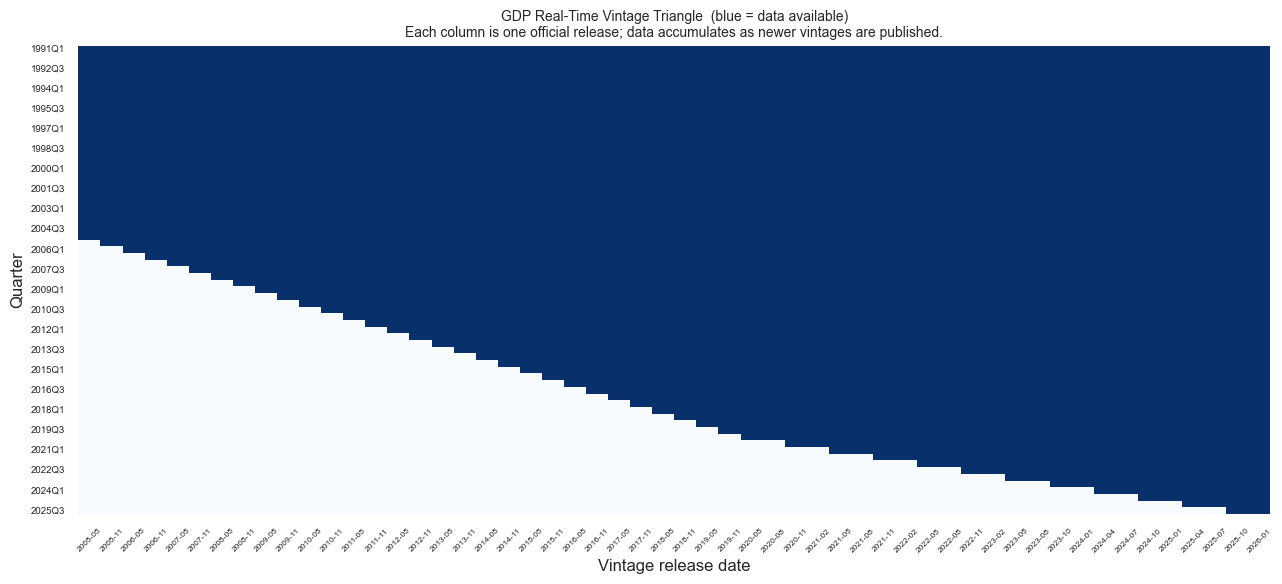

In [8]:
# --- Vintage triangle heatmap ---
q_step = max(1, gdp_vintages.shape[0] // 50)
v_step = max(1, gdp_vintages.shape[1] // 50)
hm = gdp_vintages.iloc[::q_step, ::v_step].notna().astype(int)
hm.index   = [str(p) for p in hm.index]
hm.columns = [c.strftime('%Y-%m') for c in hm.columns]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(hm, cmap='Blues', cbar=False, linewidths=0, ax=ax)
ax.set_title(
    'GDP Real-Time Vintage Triangle  (blue = data available)\n'
    'Each column is one official release; data accumulates as newer vintages are published.',
    fontsize=10
)
ax.set_xlabel('Vintage release date')
ax.set_ylabel('Quarter')
ax.tick_params(axis='x', labelsize=6, rotation=45)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gdp_vintage_triangle.png', dpi=150)
plt.show()

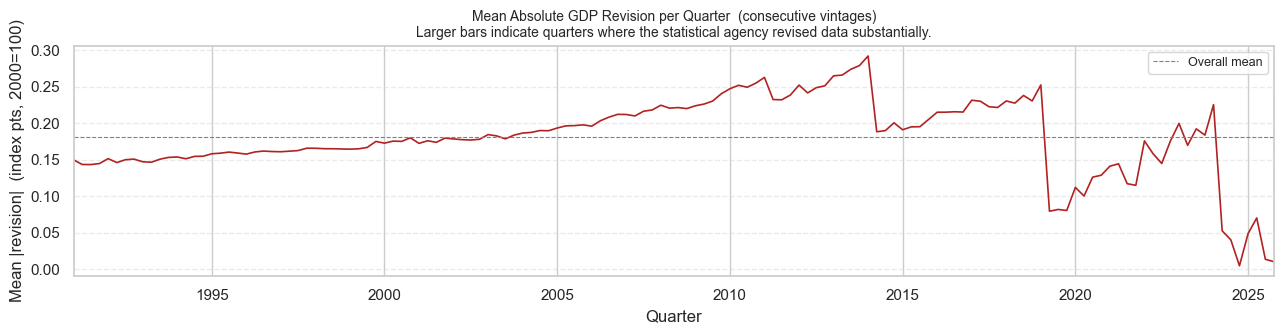

Top 10 most-revised quarters (by mean absolute revision):
         mean_abs_revision
Quarter                   
2014Q1            0.291972
2013Q4            0.278889
2013Q3            0.273836
2013Q2            0.265811
2013Q1            0.264800
2011Q1            0.262651
2010Q4            0.254762
2019Q1            0.252353
2012Q1            0.252152
2010Q2            0.251860


In [9]:
# --- GDP revision magnitude ---
# revision[q, v] = value in vintage v  minus  value in vintage v-1
gdp_revisions  = gdp_vintages.diff(axis=1)
mean_abs_rev   = gdp_revisions.abs().mean(axis=1).dropna()

fig, ax = plt.subplots(figsize=(13, 3.5))
mean_abs_rev.plot(ax=ax, color='firebrick', linewidth=1.2)
ax.axhline(mean_abs_rev.mean(), linestyle='--', color='grey', linewidth=0.8, label='Overall mean')
ax.set_title(
    'Mean Absolute GDP Revision per Quarter  (consecutive vintages)\n'
    'Larger bars indicate quarters where the statistical agency revised data substantially.',
    fontsize=10
)
ax.set_xlabel('Quarter')
ax.set_ylabel('Mean |revision|  (index pts, 2000=100)')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gdp_revisions.png', dpi=150)
plt.show()

print("Top 10 most-revised quarters (by mean absolute revision):")
top10 = mean_abs_rev.sort_values(ascending=False).head(10)
display_df = top10.to_frame('mean_abs_revision')
display_df.index.name = 'Quarter'
print(display_df.to_string())

---
## Step 5 — Data Quality Analysis

We assess the predictor panel (`data_df`) across four dimensions:

1. **Missing values** — overall pattern and block-level breakdown
2. **Coverage table** — first/last observation dates and share of missing values per indicator
3. **Stale indicators** — series that have stopped updating before the end of the sample
4. **Duplicate detection** — exact column equality and near-perfect Pearson correlates (|r| ≥ 0.9999)

### 5.1 Missing Value Heatmap by Block

Rather than plotting 653 individual series (which becomes unreadable), we aggregate by **block**:  
each cell shows the percentage of indicators in that block that are missing at that point in time.  
This reveals *which economic sectors* have data gaps and *when* they appear.

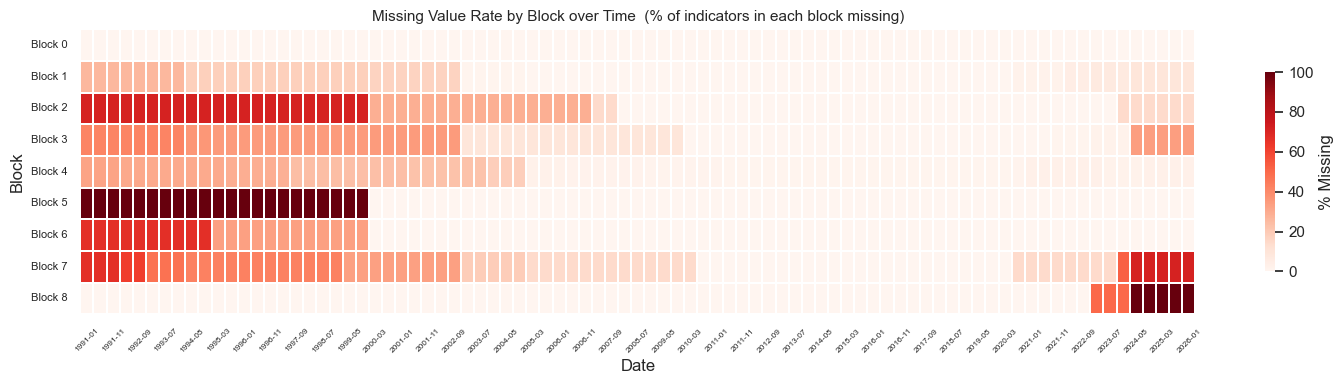

In [10]:
# --- 5.1  Block-level missing value heatmap ---
block_series = data_dict['block']

# For each block, compute monthly % missing across its indicators
blocks_present = sorted(block_series.dropna().unique())
block_missing  = {}
for b in blocks_present:
    ids = block_series[block_series == b].index.tolist()
    ids = [i for i in ids if i in data_df.columns]
    if ids:
        block_missing[f'Block {int(b)}'] = data_df[ids].isna().mean(axis=1).mul(100)

block_miss_df = pd.DataFrame(block_missing)  # shape: (N_months, N_blocks)

# Subsample time axis for readability
t_step = max(1, len(block_miss_df) // 80)
hm2 = block_miss_df.iloc[::t_step].T
hm2.columns = [d.strftime('%Y-%m') for d in hm2.columns]

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(
    hm2, cmap='Reds', vmin=0, vmax=100,
    cbar_kws={'label': '% Missing', 'shrink': 0.7},
    linewidths=0.3, ax=ax
)
ax.set_title(
    'Missing Value Rate by Block over Time  (% of indicators in each block missing)',
    fontsize=11
)
ax.set_xlabel('Date')
ax.set_ylabel('Block')
ax.tick_params(axis='x', labelsize=6, rotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'missing_by_block.png', dpi=150)
plt.show()

### 5.2 Coverage Table & Stale Indicators

The **coverage table** records — for each indicator — the date of its first and last non-missing observation, the total number of observations, and the percentage of missing values over the full sample.

The coverage table is the input to the 30% non-missing screen used at each origin. Series that stop well before the sample end are treated as discontinued in notebook 02. Late-starting series fail the coverage screen in early windows. Publication lags are applied later, in the nowcasting notebooks, not by dropping series from the selection matrices.


In [11]:
def build_coverage_table(data_df: pd.DataFrame, data_dict: pd.DataFrame) -> pd.DataFrame:
    """
    Build a per-indicator coverage summary enriched with metadata.

    Returns
    -------
    coverage : DataFrame with columns:
        first_date, last_date, n_obs, pct_missing, months_to_end,
        name, category, block, trafo
    """
    sample_end = data_df.index.max()

    cov = pd.DataFrame({
        'first_date'   : data_df.apply(lambda s: s.first_valid_index()),
        'last_date'    : data_df.apply(lambda s: s.last_valid_index()),
        'n_obs'        : data_df.notna().sum(),
        'pct_missing'  : data_df.isna().mean().mul(100).round(1),
    })
    cov.index.name = 'id'

    cov['months_to_end'] = (
        (sample_end - cov['last_date']).dt.days / 30.44
    ).round(1)

    # Enrich with metadata
    for col in ['name', 'category', 'block', 'trafo']:
        if col in data_dict.columns:
            cov[col] = data_dict[col]

    return cov.sort_values('last_date')


coverage = build_coverage_table(data_df, data_dict)
print(f'Coverage table: {coverage.shape[0]} indicators')
print()
print('Sample — indicators with earliest last observation:')
print(coverage[['last_date', 'first_date', 'n_obs', 'pct_missing', 'months_to_end', 'category']].head(10).to_string())

Coverage table: 653 indicators

Sample — indicators with earliest last observation:
                                    last_date first_date  n_obs  pct_missing  months_to_end   category
id                                                                                                    
ih:mb:com:cons_conf_world_weighted 2020-02-01 2005-01-01    182         57.1           73.9     Global
detrad1827                         2020-03-01 1991-01-01    351         17.2           73.0   Turnover
ih:mb:com:pmi_world_weighted       2020-03-01 2005-01-01    183         56.8           73.0     Global
buba_mb_04314                      2020-04-01 1991-01-01    352         17.0           72.0  Financial
buba_mb_105952                     2020-05-01 1993-01-01    329         22.4           71.0     Prices
buba_mb_69498                      2020-05-01 1993-01-01    329         22.4           71.0     Prices
deprod2431                         2020-06-01 1991-01-01    354         16.5           70.0 

In [12]:
# --- Stale indicators summary (last obs before Q4 2025) ---
CUTOFF_Q = pd.Period('2025Q4', freq='Q')
CUTOFF_LAST_DATE = CUTOFF_Q.end_time  # This gives the last possible day in Q4 2025
stale_all = coverage[coverage['last_date'] < CUTOFF_LAST_DATE].copy()
print(f'{len(stale_all)} stale indicators (last obs before {CUTOFF_Q} / {CUTOFF_LAST_DATE.strftime("%Y-%m-%d")})')

70 stale indicators (last obs before 2025Q4 / 2025-12-31)


---
### 5.3 Duplicate Detection

In a high-dimensional predictor panel assembled from multiple data providers (Macrobond, ECB, Bundesbank, ifo, OECD), the same underlying economic time series frequently appears under different codes — as a headline aggregate and a constituent sub-index, or in overlapping releases from different providers.

Exact duplicates add no information. Near-perfect linear correlates make the elastic-net active set unstable (the ℓ1 penalty splits weight arbitrarily between near-identical columns) and inflate DFM loadings (Bai & Ng 2002; Belloni, Chernozhukov & Hansen 2014; Stock & Watson 2016).

**Strategy:** two automatic checks on `data_df` (raw levels), plus a short documented manual list.

1. **Exact equality** — column-wise byte-for-byte match including NaN pattern.
2. **Near-perfect linear correlation** — Pearson |r| ≥ `CORR_THRESHOLD` on the upper triangle of the pairwise correlation matrix.
3. **Manual duplicates list** — explicit pairs whose correlation falls below the threshold but that are *documented* to represent the same economic quantity (typical case: a series and its moving-average version).

#### Choice of `CORR_THRESHOLD`

The threshold is chosen empirically from the pairwise correlation distribution of the panel itself, not by fiat:

| Threshold | # pairs | Interpretation |
|-----------:|-------:|---|
| 0.9999 | 23  | exact-match duplicates only |
| **0.999**  | **39**  | **near-identical series — the cut-off used below** |
| 0.998  | 60  | begins to include distinct-but-highly-correlated sub-aggregates |
| 0.995  | 114 | flags genuinely different sectoral cuts (too aggressive) |
| 0.99   | 162 | economic co-movement, not redundancy |

`|r| ≥ 0.999` is the natural elbow: above it, the pairs are informationally indistinguishable; below it, pairs begin to reflect genuine macro co-movement that the modelling stage should retain.

#### Keep/drop rule (applied deterministically to each flagged pair)

1. Prefer the ID with `factor_data == 1` (already validated by the ifoCAST factor set).
2. Else prefer the ID with wider coverage (later `last_date`, earlier `first_date`).
3. Else prefer the native provider (DG ECFIN / Bundesbank / Destatis) over an OECD re-publication (`oecd_econ_*`).
4. Else keep the alphabetically smaller ID (deterministic tie-break).

The per-pair decision is exported to `deduplication_decisions.csv` and **applied in `02_data_preparation.ipynb`** at the start of the notebook, before any transformation or stationarity test.


In [13]:
# --- 5.4.1  Exact duplicate columns ---
_NaN = '__NaN__'   # sentinel: NaN-safe hashable key


def _col_key(series: pd.Series) -> tuple:
    """Return a hashable, NaN-safe representation of a series."""
    return tuple(_NaN if pd.isna(v) else v for v in series)


# Group all columns by value fingerprint
_key_map: dict[tuple, list[str]] = {}
for _col_id in data_df.columns:
    _k = _col_key(data_df[_col_id])
    _key_map.setdefault(_k, []).append(_col_id)

exact_groups    = [g for g in _key_map.values() if len(g) > 1]
n_exact_total   = sum(len(g)     for g in exact_groups)   # columns involved
n_exact_extra   = sum(len(g) - 1 for g in exact_groups)   # redundant copies

print(f'Duplicate groups (exact value match) : {len(exact_groups)}')
print(f'Total columns in duplicate groups   : {n_exact_total}')
print(f'Redundant copies                    : {n_exact_extra}')

if exact_groups:
    rows = []
    for grp in exact_groups:
        for col_id in grp:
            m = data_dict.loc[col_id]
            rows.append({
                'id'          : col_id,
                'other_in_group': ' | '.join(g for g in grp if g != col_id),
                'category'    : m['category'],
                'block'       : int(m['block'])        if pd.notna(m['block'])        else pd.NA,
                'trafo'       : int(m['trafo'])         if pd.notna(m['trafo'])        else pd.NA,
                'factor_data' : int(m['factor_data'])   if pd.notna(m['factor_data']) else pd.NA,
                'name'        : str(m['name'])[:70],
            })
    dup_table = pd.DataFrame(rows)
    print()
    print(dup_table[['id', 'other_in_group', 'category', 'trafo', 'factor_data', 'name']].to_string(index=False))
else:
    print('\nResult: No exact duplicate columns detected in data_df.')

Duplicate groups (exact value match) : 21
Total columns in duplicate groups   : 42
Redundant copies                    : 21

                   id        other_in_group   category  trafo  factor_data                                                                   name
           deprod1375            deprod3650 Production      1            0 Germany, Industrial Production, Total, Excluding Energy & Construction
           deprod3650            deprod1375 Production      1            0 Germany, Mining & Quarrying & Manufacturing, Total, Excluding Energy, 
 indu_de_tot_cof_bs_m    oecd_econ_00056158    Surveys      0            1 Germany, Business Surveys, DG ECFIN, Industrial Confidence Indicator, 
   oecd_econ_00056158  indu_de_tot_cof_bs_m    Surveys      0            0 Germany, Economy, Leading Indicators & Tendency Surveys, Total - All A
   indu_de_tot_3_bs_m    oecd_econ_00056016    Surveys      0            1 Germany, Business Surveys, DG ECFIN, Industrial Confidence Indicator, 

In [ ]:
# --- 5.4.2  Near-perfect linear correlates + documented manual duplicates ---
# Detection strategy:
#   gate A  |r| >= CORR_THRESHOLD  on the pairwise correlation matrix.
#   gate B  MANUAL_DUPLICATES      explicit list of documented same-concept pairs whose
#                                   correlation falls below gate A (e.g. a series and its
#                                   moving-average sibling). Each entry must be justified.
CORR_THRESHOLD = 0.999   # chosen from the correlation-distribution sweep — see markdown above

# --- Documented manual duplicate pairs ---
# Format: (id_a, id_b, reason)  — one entry per documented same-concept pair.
# Only add pairs where the economic identity is unambiguous and verifiable from the name / source.
MANUAL_DUPLICATES: list[tuple[str, str, str]] = [
    ('buba_mb_04301', 'buba_mb_04305',
     'Bundesbank 3-month EURIBOR: Monthly Average vs. Moving Monthly Average of the same rate'),
]

print('Computing pairwise Pearson correlation matrix (pairwise-complete obs) ...')
corr_mat = data_df.corr()
print(f'Done.  Matrix shape: {corr_mat.shape}')

arr     = corr_mat.values
abs_arr = np.abs(arr)

# Gate A — correlation-based candidates
ii, jj  = np.where(np.triu(abs_arr >= CORR_THRESHOLD, k=1))
corr_pairs = [(corr_mat.index[i], corr_mat.columns[j], float(arr[i, j]))
              for i, j in zip(ii, jj)]

# Gate B — documented manual duplicates (retrieve their empirical r for the audit trail)
manual_pairs: list[tuple[str, str, float, str]] = []
for id_a, id_b, reason in MANUAL_DUPLICATES:
    if id_a in corr_mat.index and id_b in corr_mat.columns:
        r = float(corr_mat.at[id_a, id_b])
        manual_pairs.append((id_a, id_b, r, reason))
    else:
        print(f'WARNING: manual pair ({id_a}, {id_b}) skipped — at least one ID is missing from data_df')

# Merge gates, keep unique pairs, tag detection method
all_pairs: dict[tuple[str, str], dict] = {}
for id_a, id_b, r in corr_pairs:
    key = tuple(sorted((id_a, id_b)))
    all_pairs[key] = {'id_a': key[0], 'id_b': key[1], 'r': r,
                      'detected_by': 'correlation', 'manual_reason': ''}
for id_a, id_b, r, reason in manual_pairs:
    key = tuple(sorted((id_a, id_b)))
    if key in all_pairs:
        all_pairs[key]['detected_by']   = 'correlation+manual'
        all_pairs[key]['manual_reason'] = reason
    else:
        all_pairs[key] = {'id_a': key[0], 'id_b': key[1], 'r': r,
                          'detected_by': 'manual', 'manual_reason': reason}


def _decide_keep(id_a: str, id_b: str, r: float, dd: pd.DataFrame) -> dict:
    """
    Deterministic rule for choosing which variable to keep among a highly correlated pair.
    Prioritizes: factor_data=1 > wider time coverage > native provider > alphabetic.
    Returns: dict with {'keep': id, 'drop': id, 'rule': str}
    """
    m_a, m_b = dd.loc[id_a], dd.loc[id_b]

    # Rule 1: Prefer 'factor_data'
    fa = int(m_a['factor_data']) if pd.notna(m_a['factor_data']) else 0
    fb = int(m_b['factor_data']) if pd.notna(m_b['factor_data']) else 0
    if fa != fb:
        return {'keep': id_a if fa > fb else id_b,
                'drop': id_b if fa > fb else id_a,
                'rule': 'factor_data=1 preferred'}

    # Rule 2: Prefer longer non-missing time span
    la = data_df[id_a].last_valid_index()
    lb = data_df[id_b].last_valid_index()
    fa_d = data_df[id_a].first_valid_index()
    fb_d = data_df[id_b].first_valid_index()
    span_a = (la - fa_d).days if (la is not None and fa_d is not None) else -1
    span_b = (lb - fb_d).days if (lb is not None and fb_d is not None) else -1
    if span_a != span_b:
        return {'keep': id_a if span_a > span_b else id_b,
                'drop': id_b if span_a > span_b else id_a,
                'rule': 'wider coverage'}

    # Rule 3: Prefer native provider over OECD re-publication
    def _is_oecd(i): return i.startswith('oecd_econ_')
    if _is_oecd(id_a) != _is_oecd(id_b):
        return {'keep': id_b if _is_oecd(id_a) else id_a,
                'drop': id_a if _is_oecd(id_a) else id_b,
                'rule': 'native provider preferred'}

    # Rule 4: Alphabetic tie-break
    keep, drop = sorted((id_a, id_b))
    return {'keep': keep, 'drop': drop, 'rule': 'alphabetic tie-break'}

# --- Build deduplication decision DataFrame ---
dedup_rows = []
for (id_a, id_b), info in all_pairs.items():
    m_a, m_b = data_dict.loc[id_a], data_dict.loc[id_b]
    decision = _decide_keep(id_a, id_b, info['r'], data_dict)
    dedup_rows.append({
        'id_a'         : id_a,
        'id_b'         : id_b,
        'r'            : round(info['r'], 6),
        'detected_by'  : info['detected_by'],
        'manual_reason': info.get('manual_reason', ''),
        'keep'         : decision['keep'],
        'drop'         : decision['drop'],
        'rule'         : decision['rule'],
        'category_a'   : m_a['category'],
        'category_b'   : m_b['category'],
        'trafo_a'      : int(m_a['trafo'])       if pd.notna(m_a['trafo'])       else pd.NA,
        'trafo_b'      : int(m_b['trafo'])       if pd.notna(m_b['trafo'])       else pd.NA,
        'factor_a'     : int(m_a['factor_data']) if pd.notna(m_a['factor_data']) else pd.NA,
        'factor_b'     : int(m_b['factor_data']) if pd.notna(m_b['factor_data']) else pd.NA,
        'name_a'       : str(m_a['name'])[:70],
        'name_b'       : str(m_b['name'])[:70],
    })

near_dup_df = pd.DataFrame(dedup_rows).sort_values('r', key=lambda x: x.abs(), ascending=False)

# --- Prepare deduplication decisions dataframe (keep only one row per dropped variable) ---
decision_rows = []
for _, row in near_dup_df.iterrows():
    decision_rows.append({
        'id_drop'      : row['drop'],
        'id_keep'      : row['keep'],
        'r'            : row['r'],
        'detected_by'  : row['detected_by'],
        'manual_reason': row['manual_reason'],
        'rule'         : row['rule'],
        'name_drop'    : (str(data_dict.loc[row['drop'], 'name'])[:80]
                          if row['drop'] in data_dict.index else ''),
        'name_keep'    : (str(data_dict.loc[row['keep'], 'name'])[:80]
                          if row['keep'] in data_dict.index else ''),
    })
decisions_df = pd.DataFrame(decision_rows).drop_duplicates('id_drop')

n_corr_only   = sum(p['detected_by'] == 'correlation'        for p in all_pairs.values())
n_manual_only = sum(p['detected_by'] == 'manual'             for p in all_pairs.values())
n_both        = sum(p['detected_by'] == 'correlation+manual' for p in all_pairs.values())

print()
print(f"Near-duplicate pairs           : {len(near_dup_df)}")
print(f"  detected by correlation only (|r| ≥ {CORR_THRESHOLD}): {n_corr_only}")
print(f"  documented manual pairs                                 : {n_manual_only}")
print(f"  detected by both                                      : {n_both}")

print()
print(
    "NOTE: Each near-duplicate pair involves two highly correlated indicators. "
    "For each pair, only one variable is marked for removal (the less preferred according to "
    "clearly defined rules). If N pairs are found, you do NOT remove N*2 variables, but rather one per pair.\n"
    "However, a variable can participate in more than one pair, so the total number of unique series marked for removal "
    "may be LESS than the number of pairs found. For example, if a variable is highly correlated with several others, "
    "it is dropped only once. This often explains why the count of unique drops (below) is not simply N/2."
)
print()
print(f"Unique series marked for removal: {decisions_df.shape[0]}")

# Additional clarity for the user
if decisions_df.shape[0] < len(near_dup_df):
    print(
        "Some variables appeared in multiple correlated pairs, but are dropped only once. "
        "Hence, the number of unique variables to remove (above) is less than the number of pairs. "
        "The deduplication logic ensures no variable is double-counted."
    )

if not near_dup_df.empty:
    show_cols = ['id_a', 'id_b', 'r', 'detected_by', 'keep', 'drop', 'rule',
                 'factor_a', 'factor_b', 'name_a']
    print()
    print(near_dup_df[show_cols].to_string(index=False))

    dup_csv       = _tp.NEAR_DUPLICATE_PAIRS_CSV
    decisions_csv = _tp.DEDUPLICATION_DECISIONS_CSV
    near_dup_df.to_csv(dup_csv, index=False)
    decisions_df.to_csv(decisions_csv, index=False)
    print(f'\nSaved pair list : {dup_csv}')
    print(f'Saved decisions : {decisions_csv}')
else:
    print('Result: No near-duplicate pairs found.')


---
## Step 6 — Summary Report

> **Clarification on counts:**    
> The predictor count (653) and the GDP vintage count (108).
> GDP is the **target variable**, stored in `gdp_vintages` (quarterly, vintage-structured).

In [ ]:
SEP = '=' * 62
print(SEP)
print('  ifoCAST Dataset — Summary Report')
print(SEP)

# --- Predictor panel ---
N_ind   = data_df.shape[1]
N_months= data_df.shape[0]
t_start = data_df.index.min().strftime('%Y-%m')
t_end   = data_df.index.max().strftime('%Y-%m')
pct_miss= data_df.isna().mean().mean() * 100

eval_window = data_df.loc['1991-01':'2025-12']
fully_obs   = (eval_window.isna().sum() == 0).sum()
any_gap     = N_ind - fully_obs
stale_6m    = (coverage['months_to_end'] > 6).sum()
stale_12m   = (coverage['months_to_end'] > 12).sum()

print(f'\n--- PREDICTOR PANEL  (data_df) ---')
print(f'  Total predictors          : {N_ind}')
print(f'  Monthly time periods      : {N_months}  ({t_start} → {t_end})')
print(f'  Overall % missing         : {pct_miss:.2f}%')
print(f'  Fully observed 1991-2025  : {fully_obs} predictors  (no missing values in modelling window)')
print(f'  Predictors with any gap   : {any_gap}  (have ≥1 missing observation in 1991-2025)')
print(f'  Stale > 6 months          : {stale_6m}  (last obs >6 months before sample end)')
print(f'  Stale > 12 months         : {stale_12m}  (likely discontinued — handle with care)')

print(f'\n--- TRANSFORMATION CODES ---')
for t, n in data_dict['trafo'].value_counts().sort_index().items():
    label = {0: 'Level (stationary as-is)', 1: 'Log-difference (growth rate)', 2: 'Second log-diff'}.get(int(t), '?')
    print(f'  Trafo={t}  {label:<30s}: {n:>4d} predictors')

print(f'\n--- BLOCK DISTRIBUTION ---')
for b, n in data_dict['block'].value_counts().sort_index().items():
    print(f'  Block {b}: {n:>4d} predictors')

print(f'\n--- FACTOR DATA SUBSET ---')
n_fd = (data_dict['factor_data'] == 1).sum()
print(f'  ifoCAST factor-extraction set: {n_fd} predictors (out of {N_ind})')

# --- GDP vintage panel ---
print(f'\n--- GDP VINTAGE PANEL  (gdp_vintages) ---')
print(f'  Target variable           : German GDP index (base 2000 = 100), quarterly')
print(f'  Quarters in panel         : {gdp_vintages.shape[0]}  ({gdp_vintages.index[0]} → {gdp_vintages.index[-1]})')
print(f'  Number of vintages        : {gdp_vintages.shape[1]}')
print(f'  First vintage release     : {gdp_vintages.columns[0].strftime("%Y-%m-%d")}')
print(f'  Last  vintage release     : {gdp_vintages.columns[-1].strftime("%Y-%m-%d")}')

# --- Data quality ---
print(f'\n--- DATA QUALITY ---')
print('  Extreme observations (e.g. COVID-19, GFC): retained as genuine shocks.')
print('  No ad-hoc winsorisation; downstream transformations and regularisation handle scale.')

# --- Duplicate detection ---
print(f'\n--- DUPLICATE DETECTION ---')
print(f'  Exact duplicate groups                 : {len(exact_groups)}')
if exact_groups:
    n_extra = sum(len(g) - 1 for g in exact_groups)
    print(f'  Redundant copies (exact)               : {n_extra}')
print(f'  Near-duplicate pairs (|r|≥{CORR_THRESHOLD} or manual)   : {len(near_dup_df)}')
if not near_dup_df.empty:
    print(f'  Unique IDs marked for removal          : {decisions_df.shape[0]}')
    print(f'  → Applied at the start of 02_data_preparation')

# --- Output files ---
print(f'\n--- OUTPUT FILES ---')
print(f'  {_tp.PANEL_RAW_CSV}                      ← predictor panel')
print(f'  {_tp.DATA_DICT_CATALOG_CSV}                    ← variable catalogue')
if not near_dup_df.empty:
    print(f'  {_tp.DEDUPLICATION_DECISIONS_CSV}   ← keep/drop decisions')
    print(f'  {_tp.NEAR_DUPLICATE_PAIRS_CSV}      ← near-duplicate flag list')
print(f'  {FIG_DIR}/                                     ← all figures')

print(f'\n{SEP}')
